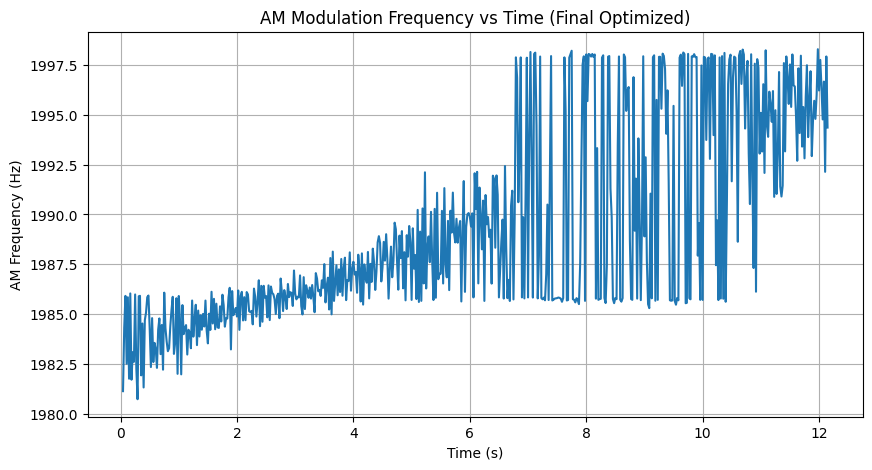

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, hilbert, get_window, decimate

# -----------------------------
# LOAD
# -----------------------------
fs, signal = wavfile.read(r'E:\Carry Chun\1_12-38-05_434400000Hz.wav')

if len(signal.shape) > 1:
    signal = signal[:, 0]

signal = signal.astype(np.float32)
signal /= np.max(np.abs(signal))

# -----------------------------
# PARAMETERS
# -----------------------------
chunk_size = 200000
step = chunk_size // 4

fmin, fmax = 10, 5000  # Hz

times = []
am_freqs = []

# -----------------------------
# FILTER
# -----------------------------
def lowpass(data, cutoff, fs, order=4):
    b, a = butter(order, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, data)

# -----------------------------
# PARABOLIC INTERPOLATION
# -----------------------------
def refine_peak(freqs, spectrum, idx):
    if idx <= 0 or idx >= len(spectrum) - 1:
        return freqs[idx]

    alpha = spectrum[idx - 1]
    beta  = spectrum[idx]
    gamma = spectrum[idx + 1]

    denom = (alpha - 2*beta + gamma)
    if denom == 0:
        return freqs[idx]

    delta = 0.5 * (alpha - gamma) / denom
    return freqs[idx] + delta * (freqs[1] - freqs[0])

# -----------------------------
# PROCESS
# -----------------------------
for start in range(0, len(signal) - chunk_size, step):
    chunk = signal[start:start + chunk_size]
    chunk -= np.mean(chunk)

    # 1. Envelope via Hilbert
    analytic = hilbert(chunk)
    envelope = np.abs(analytic)

    # 2. Low-pass
    envelope = lowpass(envelope, fmax, fs)
    envelope -= np.mean(envelope)

    # 3. 🔻 Downsample AFTER filtering
    ds_factor = int(fs // (10 * fmax))  # ~10x Nyquist margin
    if ds_factor > 1:
        envelope = envelope[::ds_factor]
        fs_env = fs // ds_factor
    else:
        fs_env = fs

    # 4. Window
    window = get_window("hann", len(envelope))
    env_win = envelope * window

    # 5. FFT
    fft_vals = np.fft.rfft(env_win)
    freqs = np.fft.rfftfreq(len(env_win), d=1/fs_env)

    spectrum = np.abs(fft_vals)

    # 6. Smooth spectrum (reduces noise spikes)
    spectrum = np.convolve(spectrum, np.ones(5)/5, mode='same')

    # 7. Band-limited search
    mask = (freqs >= fmin) & (freqs <= fmax)

    if np.any(mask):
        sub_spec = spectrum[mask]
        sub_freqs = freqs[mask]

        idx = np.argmax(sub_spec)

        # 8. Refine peak
        am_freq = refine_peak(sub_freqs, sub_spec, idx)
    else:
        am_freq = 0

    # Time
    t = (start + chunk_size/2) / fs

    times.append(t)
    am_freqs.append(am_freq)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(times, am_freqs)
plt.xlabel("Time (s)")
plt.ylabel("AM Frequency (Hz)")
plt.title("AM Modulation Frequency vs Time (Final Optimized)")
plt.grid()
plt.show()

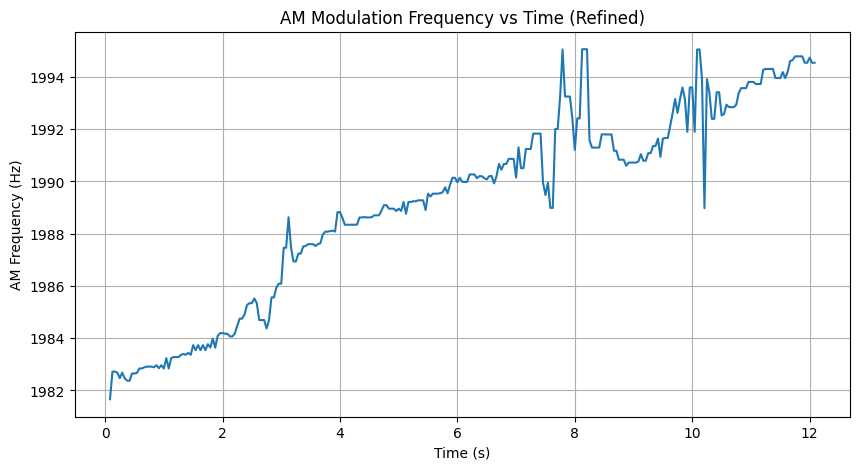

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, hilbert, get_window, medfilt

# -----------------------------
# LOAD
# -----------------------------
fs, signal = wavfile.read(r'E:\Carry Chun\1_12-38-05_434400000Hz.wav')

if len(signal.shape) > 1:
    signal = signal[:, 0]

signal = signal.astype(np.float32)
signal /= np.max(np.abs(signal))

# -----------------------------
# USER PARAMETERS
# -----------------------------
fmin, fmax = 10, 5000       # Hz
target_df = 2               # desired resolution (Hz)

# Compute chunk size from resolution
chunk_size = int(fs / target_df)
chunk_size = min(chunk_size, 400000)   # prevent huge chunks

step = chunk_size // 4

times = []
am_freqs = []

# -----------------------------
# FILTER
# -----------------------------
def lowpass(data, cutoff, fs, order=4):
    b, a = butter(order, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, data)

# -----------------------------
# PARABOLIC PEAK
# -----------------------------
def refine_peak(freqs, spectrum, idx):
    if idx <= 0 or idx >= len(spectrum)-1:
        return freqs[idx]

    alpha, beta, gamma = spectrum[idx-1], spectrum[idx], spectrum[idx+1]
    denom = (alpha - 2*beta + gamma)

    if denom == 0:
        return freqs[idx]

    delta = 0.5 * (alpha - gamma) / denom
    return freqs[idx] + delta * (freqs[1] - freqs[0])

# -----------------------------
# PROCESS
# -----------------------------
for start in range(0, len(signal) - chunk_size, step):
    chunk = signal[start:start + chunk_size]
    chunk -= np.mean(chunk)

    # 1. Envelope
    analytic = hilbert(chunk)
    envelope = np.abs(analytic)

    # 2. Low-pass
    envelope = lowpass(envelope, fmax, fs)
    envelope -= np.mean(envelope)

    # -----------------------------
    # SMART DOWNSAMPLING
    # -----------------------------
    max_ds = int(fs / (5 * fmax))  # keep ≥5× bandwidth
    ds_factor = max(1, min(max_ds, 20))  # cap at 20 (safe)

    if ds_factor > 1:
        envelope = envelope[::ds_factor]
        fs_env = fs // ds_factor
    else:
        fs_env = fs

    # Ensure enough samples
    if len(envelope) < 4096:
        continue

    # 3. Window
    window = get_window("hann", len(envelope))
    env_win = envelope * window

    # 4. FFT
    fft_vals = np.fft.rfft(env_win)
    freqs = np.fft.rfftfreq(len(env_win), d=1/fs_env)
    spectrum = np.abs(fft_vals)

    # Smooth spectrum
    spectrum = np.convolve(spectrum, np.ones(5)/5, mode='same')

    # 5. Band-limited search
    mask = (freqs >= fmin) & (freqs <= fmax)

    if np.any(mask):
        sub_spec = spectrum[mask]
        sub_freqs = freqs[mask]

        idx = np.argmax(sub_spec)

        # Peak quality check (reject weak peaks)
        if sub_spec[idx] < 3 * np.median(sub_spec):
            am_freq = np.nan
        else:
            am_freq = refine_peak(sub_freqs, sub_spec, idx)
    else:
        am_freq = np.nan

    t = (start + chunk_size/2) / fs

    times.append(t)
    am_freqs.append(am_freq)

# -----------------------------
# TEMPORAL SMOOTHING
# -----------------------------
am_freqs = np.array(am_freqs)

# Remove NaNs for filtering
valid = ~np.isnan(am_freqs)
am_freqs[valid] = medfilt(am_freqs[valid], kernel_size=5)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(times, am_freqs, linewidth=1.5)
plt.xlabel("Time (s)")
plt.ylabel("AM Frequency (Hz)")
plt.title("AM Modulation Frequency vs Time (Refined)")
plt.grid()
plt.show()